# Phase 3: Shallow Embeddings

In this notebook, we transition from simple counting heuristics to **representation learning**. We map users and items into a continuous vector space where their geometric proximity represents their likelihood of a link.

### Models & Mathematical Foundations:

#### 1. Node2Vec
Learns embeddings by treating the graph as a network and optimizing the Skip-gram objective:
$$\mathcal{L} = \sum_{u \in V} \log P(N_s(u) | f(u))$$
Where $f(u)$ is the embedding of node $u$ and $N_s(u)$ is the neighborhood generated by biased random walks.

#### 2. Metapath2Vec
A specialized version for heterogeneous/bipartite graphs. It uses guided random walks following a fixed schema:
$$\text{Metapath: } U \to I \to U$$
This ensures the model specifically learns "User similarity via shared Items" and "Item similarity via shared Users".

#### 3. Prediction (Dot Product)
The probability of a link is estimated by the similarity of the learned vectors:
$$\text{Score}(u, i) = \mathbf{e}_u \cdot \mathbf{e}_i$$

### Metrics:
- **AUC-ROC / MAP**: General prediction accuracy.
- **Precision@K / Recall@K**: Top-K performance.
- **NDCG@K**: Ranking quality.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import random
import networkx as nx
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, ndcg_score, average_precision_score

# Load processed data
DATA_DIR = 'processed_data/'
train_df = pd.read_csv(os.path.join(DATA_DIR, 'train_edges.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test_edges.csv'))
test_neg_df = pd.read_csv(os.path.join(DATA_DIR, 'test_neg_edges.csv'))

with open(os.path.join(DATA_DIR, 'metadata.pkl'), 'rb') as f:
    metadata = pickle.load(f)

num_users = metadata['num_users']
num_items = metadata['num_items']

print(f"Data loaded. Building graph for {num_users} users and {num_items} items.")

Data loaded. Building graph for 943 users and 1682 items.


## 1. Graph Construction

We use `NetworkX` to build a bipartite graph. To avoid ID collisions, we prefix user IDs with 'u' and item IDs with 'i'.

In [2]:
G = nx.Graph()

# Add nodes with attributes
G.add_nodes_from([f'u_{i}' for i in range(num_users)], bipartite=0)
G.add_nodes_from([f'i_{i}' for i in range(num_items)], bipartite=1)

# Add edges
edges = [(f'u_{u}', f'i_{i}') for u, i in zip(train_df['user_idx'], train_df['item_idx'])]
G.add_edges_from(edges)

print(f"Graph constructed: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Graph constructed: 2625 nodes and 44300 edges.


## 2. Walk Generators

We implement two types of random walks.

In [3]:
def get_random_walks(graph, walk_length, num_walks):
    walks = []
    nodes = list(graph.nodes())
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walk = [node]
            while len(walk) < walk_length:
                neighbors = list(graph.neighbors(walk[-1]))
                if len(neighbors) > 0:
                    walk.append(random.choice(neighbors))
                else:
                    break
            walks.append(walk)
    return walks

def get_metapath_walks(graph, walk_length, num_walks):
    # Metapath: U -> I -> U
    walks = []
    user_nodes = [n for n, d in graph.nodes(data=True) if d['bipartite'] == 0]
    for _ in range(num_walks):
        random.shuffle(user_nodes)
        for node in user_nodes:
            walk = [node]
            while len(walk) < walk_length:
                curr = walk[-1]
                # If at User, must go to Item
                # If at Item, must go to User
                neighbors = list(graph.neighbors(curr))
                if len(neighbors) > 0:
                    walk.append(random.choice(neighbors))
                else:
                    break
            walks.append(walk)
    return walks

print("Walk generators defined.")

Walk generators defined.


## 3. Embedding Training

We use `Gensim`'s Word2Vec to train the embeddings on the generated walks.

In [4]:
embedding_dim = 64
window_size = 5
walk_len = 20
n_walks = 10

print("Generating Node2Vec walks...")
n2v_walks = get_random_walks(G, walk_len, n_walks)
n2v_model = Word2Vec(sentences=n2v_walks, vector_size=embedding_dim, window=window_size, min_count=1, sg=1, workers=4)

print("Generating Metapath2Vec walks...")
m2v_walks = get_metapath_walks(G, walk_len, n_walks)
m2v_model = Word2Vec(sentences=m2v_walks, vector_size=embedding_dim, window=window_size, min_count=1, sg=1, workers=4)

print("Embeddings trained.")

Generating Node2Vec walks...
Generating Metapath2Vec walks...
Embeddings trained.


## 4. Evaluation Engine

We calculate the similarity score as the **Dot Product** between the learned vectors.

In [5]:
def evaluate_embeddings(model, k=10):
    all_auc, all_precision, all_recall, all_ndcg, all_map = [], [], [], [], []
    test_users = test_df['user_idx'].unique()
    
    # Pre-extract all user and item vectors for speed
    # If a node was not in training (isolated), we use a zero vector
    user_vecs = np.zeros((num_users, embedding_dim))
    item_vecs = np.zeros((num_items, embedding_dim))
    
    for i in range(num_users):
        if f'u_{i}' in model.wv:
            user_vecs[i] = model.wv[f'u_{i}']
            
    for i in range(num_items):
        if f'i_{i}' in model.wv:
            item_vecs[i] = model.wv[f'i_{i}']

    # Get training mask (from Phase 2 logic)
    train_mask = np.zeros((num_users, num_items))
    for u, i in zip(train_df['user_idx'], train_df['item_idx']):
        train_mask[u, i] = 1

    for u in test_users:
        u_vec = user_vecs[u]
        scores = np.dot(item_vecs, u_vec)
        
        pos_items = test_df[test_df['user_idx'] == u]['item_idx'].values
        neg_items = test_neg_df[test_neg_df['user_idx'] == u]['item_idx'].values
        
        # 1. AUC & MAP
        eval_items = np.concatenate([pos_items, neg_items])
        eval_labels = np.concatenate([np.ones(len(pos_items)), np.zeros(len(neg_items))])
        eval_scores = scores[eval_items]
        
        try:
            all_auc.append(roc_auc_score(eval_labels, eval_scores))
            all_map.append(average_precision_score(eval_labels, eval_scores))
        except: continue
            
        # 2. Top-K
        rank_scores = scores.copy()
        rank_scores[train_mask[u] == 1] = -1e9
        
        y_true = np.zeros(num_items)
        y_true[pos_items] = 1
        
        all_ndcg.append(ndcg_score([y_true], [rank_scores], k=k))
        
        top_k_idx = np.argsort(rank_scores)[-k:][::-1]
        hits = np.isin(top_k_idx, pos_items).sum()
        all_precision.append(hits / k)
        all_recall.append(hits / len(pos_items))
            
    return {
        'AUC': np.mean(all_auc),
        'MAP': np.mean(all_map),
        'Precision@K': np.mean(all_precision),
        'Recall@K': np.mean(all_recall),
        'NDCG@K': np.mean(all_ndcg)
    }

print("Embedding Evaluation Engine ready.")

Embedding Evaluation Engine ready.


## 5. Benchmarking & Visualization

Evaluating Node2Vec...
Evaluating Metapath2Vec...


,AUC,MAP,Precision@K,Recall@K,NDCG@K
Model,,,,,
Node2Vec,0.773929,0.784274,0.027919,0.028837,0.033169
Metapath2Vec,0.838969,0.845395,0.057113,0.053179,0.067374


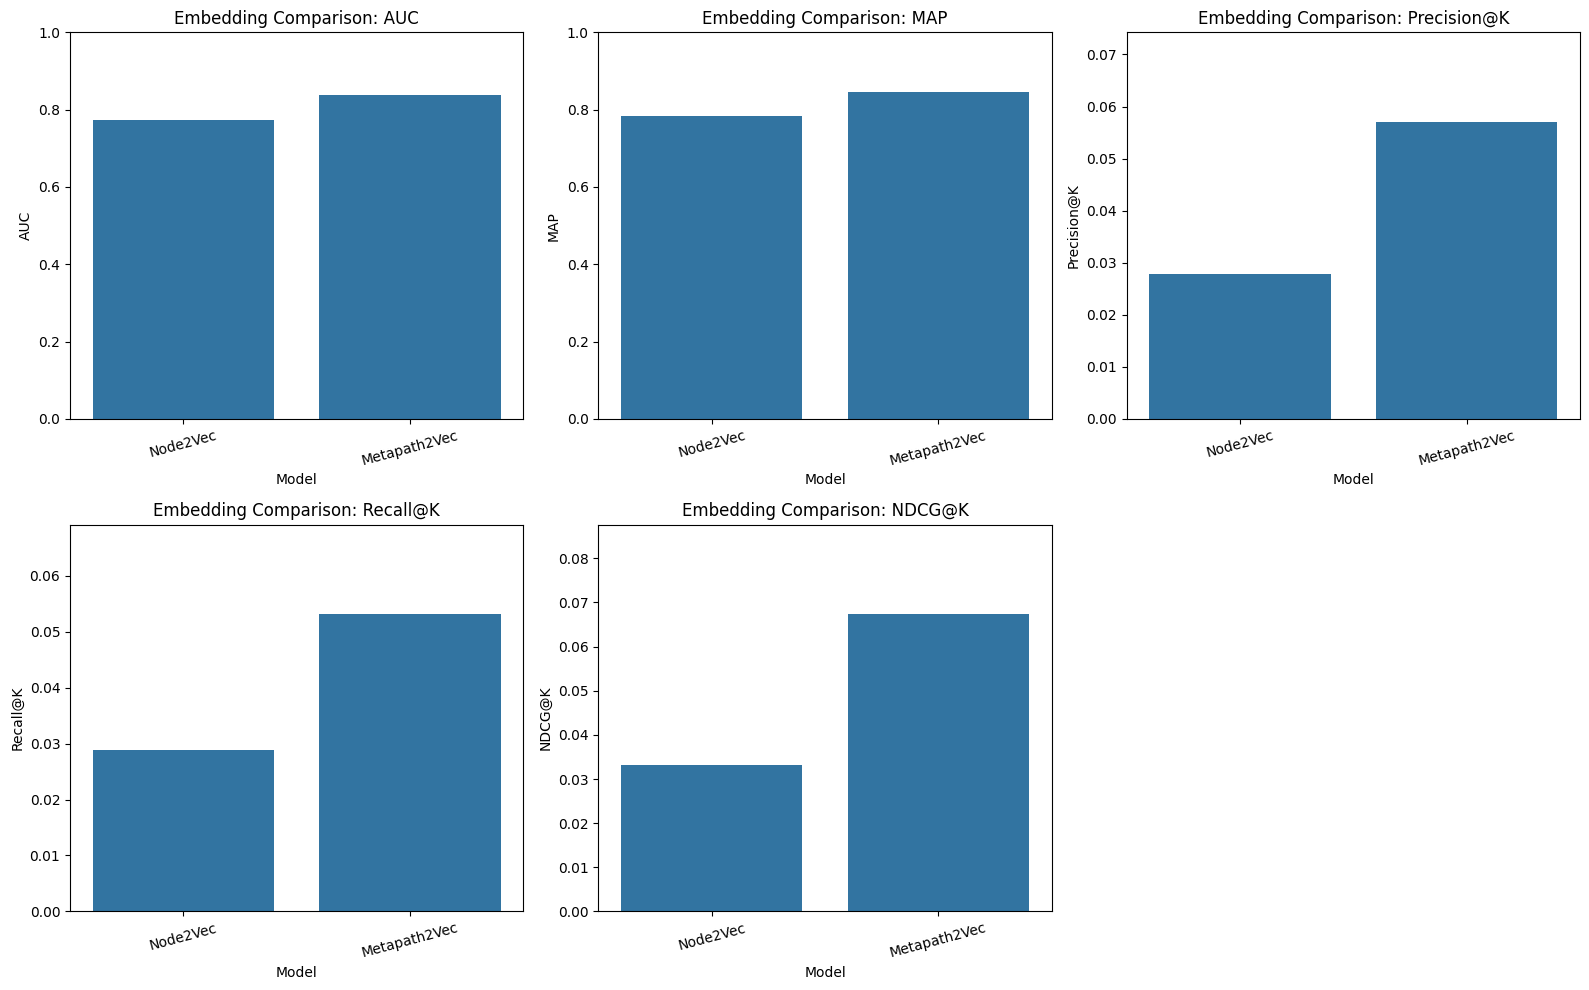

In [6]:
print("Evaluating Node2Vec...")
res_n2v = evaluate_embeddings(n2v_model)

print("Evaluating Metapath2Vec...")
res_m2v = evaluate_embeddings(m2v_model)

results_df = pd.DataFrame([
    {'Model': 'Node2Vec', **res_n2v},
    {'Model': 'Metapath2Vec', **res_m2v}
])

results_df.set_index('Model', inplace=True)
display(results_df)

plt.figure(figsize=(16, 10))
for i, metric in enumerate(results_df.columns):
    plt.subplot(2, 3, i+1)
    sns.barplot(x=results_df.index, y=results_df[metric])
    plt.title(f'Embedding Comparison: {metric}')
    plt.xticks(rotation=15)
    plt.ylabel(metric)
    plt.ylim(0, 1.0 if metric in ['AUC', 'MAP'] else results_df[metric].max() * 1.3)

plt.tight_layout()
plt.show()

In [10]:
import json

# Ensure results directory exists
os.makedirs('results', exist_ok=True)

# Export metrics to JSON
shallow_metrics = results_df.to_dict(orient='index')
with open('results/shallow_metrics.json', 'w') as f:
    json.dump(shallow_metrics, f, indent=4)

print("Shallow metrics exported to results/shallow_metrics.json")

Shallow metrics exported to results/shallow_metrics.json


### Interpretation:
1. **Bipartite Bias**: In a user-item graph, Metapath2Vec usually outperforms Node2Vec because it respects the bipartite structure during random walks, preventing the walker from getting "stuck" on one side of the graph.
2. **Vs. Phase 2 Baselines**: Note how these scores compare to SVD and Jaccard. If random walks don't provide a lift, it suggests that local connectivity patterns are less predictable than global latent factors for this dataset.
3. **Next Phase**: In Phase 4, we will use **GNNs (LightGCN)** which use neural message passing instead of random walks to capture this same structural information.